# Basic Example with one Graph
In this example, we will train a NN on a single graph dataset (for simplicity). We will be able to feed in any arbitrarily translated graph, and then predict the perturbed translation values.

In [1]:
import random

import torch
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool

print(torch.__version__)

C:\Users\jackd\source\colmap-experiments\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.9.0+cu128


## Load the data

In [2]:
import pycolmap
import pathlib
import utils.subset

# Load the Colmap data into a torch dataset
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')
reconstruction = pycolmap.Reconstruction(model_path)

graph_data = utils.subset.reconstruction_to_pyg_data(reconstruction)
graph_data

Data(x=[69, 3], edge_index=[2, 3686])

In [63]:
# Now, let's run two graph networks through it to make sure the sizes all line up
import utils.subset
import random

random.seed(42) # for reproducibility

# Sample images into disjoint sets
a_ids, b_ids = utils.subset.sample_image_subsets(reconstruction)

# Convert the reconstruction data into two sub-graphs
graph_a = utils.subset.reconstruction_to_pyg_data(reconstruction, a_ids)
graph_b = utils.subset.reconstruction_to_pyg_data(reconstruction, b_ids)

In [64]:
import utils.vis
# visualize the data
utils.vis.plot_3D_graph(graph_a, graph_b)

## Set up training loop

In [65]:
# First, let's define our "training data" and "validation data"
# These data are just a set of translation perturbations

# Seed random generator for reproducibility
torch.manual_seed(42)

# We will create 80 training examples and 20 validation perturbations
training_perturbs   = torch.empty(80, 3).uniform_(-10.0, 10.0)
validation_perturbs = torch.empty(20, 3).uniform_(-10.0, 10.0)

In [109]:
# Clone subgraph_b and perturb it for each data point
training_data = []
validation_data = []
for training_perturbation in training_perturbs:
    new_graph = graph_b.clone()
    # Add the perturbation to create a new graph
    new_graph.x = new_graph.x + training_perturbation
    # Training data is: graph, perturbation
    training_data.append([new_graph, training_perturbation])

# Do similar for validation data
for validation_perturbation in validation_perturbs:
    new_graph = graph_b.clone()
    new_graph.x = new_graph.x + validation_perturbation
    validation_data.append([new_graph, validation_perturbation])

In [110]:
x, y = training_data[0]
print(x)
print(y)

Data(x=[33, 3], edge_index=[2, 940])
tensor([ 7.6454,  8.3001, -2.3427])


In [166]:
from models import SiameseGCN_v1
import numpy as np

model = SiameseGCN_v1(graph_a.num_features)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.0001, momentum=0.9)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.1)
criterion = nn.MSELoss()
num_epochs = 200

# Keep track of loss for plotting
epoch_losses_train = []
epoch_losses_val = np.full(num_epochs, np.nan)  # one slot per epoch

for epoch in range(num_epochs):
    model.train()
    # First, shuffle the training data
    train_n = len(training_data)
    shuffled_idx = torch.randperm(train_n)
    epoch_loss = 0
    for shuffle_id in shuffled_idx:
        # Sample the training data
        graph, target = training_data[shuffle_id]
        # Unsqueeze from (3) to (1,3) to match the shape of the prediction output
        # (This is to accommodate our unused batch dimension, which we may accommodate later)
        target = target.unsqueeze(0)
        optimizer.zero_grad()
        # We will use just graph_a as first slo input for now. later, we get more fancy
        out = model(graph_a, graph)
        loss = criterion(out, target)
        # compute gradient
        loss.backward()
        # update weights
        optimizer.step()
        # Keep track of losses for logging
        epoch_loss += loss.item()
    epoch_losses_train.append(epoch_loss / train_n)

    # Calculate validation loss
    if epoch % 10 == 0:
        model.eval()
        validation_loss = 0.0
        with torch.no_grad():
            for val_datum in validation_data:
                prediction = model(graph_a, val_datum[0])
                label = val_datum[1].unsqueeze(0)
                loss = criterion(prediction, val_datum[1])
                validation_loss += loss.item()
        # Calculate average loss over the validation dataset
        epoch_losses_val[epoch] = validation_loss / len(validation_data)

    # Step the learning rate decay schedule
    scheduler.step()

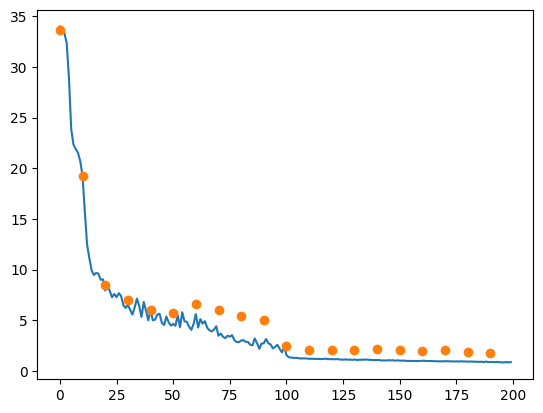

In [167]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()

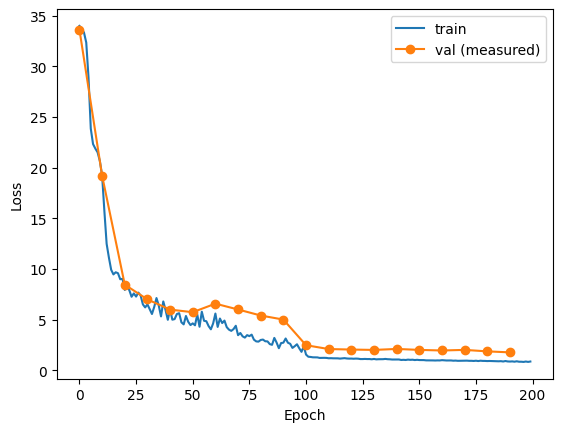

In [168]:
val_idx = np.where(~np.isnan(epoch_losses_val))[0]
val_vals = epoch_losses_val[val_idx]

plt.figure()
epochs = np.arange(num_epochs)
plt.plot(epochs, epoch_losses_train, label='train')
plt.plot(val_idx, val_vals, label='val (measured)', marker='o', linestyle='-')  # connects measured points
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predict

## Predict Training Data

In [169]:
# Example prediction
x, y = training_data[0]
print(x)
print(y)
model.eval()
prediction = model(graph_a, x)
print(prediction)

Data(x=[33, 3], edge_index=[2, 940])
tensor([ 7.6454,  8.3001, -2.3427])
tensor([[ 7.3561,  8.1709, -2.5844]], grad_fn=<AddmmBackward0>)


In [170]:
# Plat example from training data prediction
import utils.vis
# visualize the original data
utils.vis.plot_3D_graph(graph_a, x)

predicted_graph = x.clone()
predicted_graph.x -= prediction
utils.vis.plot_3D_graph(graph_a, predicted_graph)


## Predict Validation Data

In [171]:
# Example prediction
val_x, val_y = validation_data[0]
print(val_x)
print(val_y)
model.eval()
prediction = model(graph_a, val_x)
print(prediction)

Data(x=[33, 3], edge_index=[2, 940])
tensor([ 4.0936, -4.9097, -2.0125])
tensor([[ 4.5150, -5.5196, -1.2285]], grad_fn=<AddmmBackward0>)


In [172]:
# Plot the original data
utils.vis.plot_3D_graph(graph_a, val_x)

# Plot the data with the prediction
val_x_pred = val_x.clone()
val_x_pred.x -= prediction
utils.vis.plot_3D_graph(graph_a, val_x_pred)